In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.manifold import TSNE


BIGGER_SIZE = 18

plt.rc('font', size=BIGGER_SIZE, family='serif')
plt.rc('axes', titlesize=BIGGER_SIZE)
plt.rc('axes', labelsize=BIGGER_SIZE)
plt.rc('xtick', labelsize=BIGGER_SIZE)
plt.rc('ytick', labelsize=BIGGER_SIZE)
plt.rc('legend', fontsize=BIGGER_SIZE - 4)
plt.rc('figure', titlesize=BIGGER_SIZE)

# Scenarios organized by type
multi_segment_scenarios = [
    '/home/kinrre/Documentos/robin-rl/models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/0/290326-010418/evaluation/',
    '/home/kinrre/Documentos/robin-rl/models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/41/290326-060648/evaluation/',
    '/home/kinrre/Documentos/robin-rl/models/paper/multi_segment_v3_rgcn_x2_1024_1M/graph_matd3/73/290326-100844/evaluation/',
]
extended_scenarios = [
    '/home/kinrre/Documentos/robin-rl/models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/0/250326-150907/evaluation/',
    '/home/kinrre/Documentos/robin-rl/models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/41/250326-173824/evaluation/',
    '/home/kinrre/Documentos/robin-rl/models/paper/extended_v2_rgcn_x2_1024_1M/graph_matd3/73/250326-200550/evaluation/',
]
episodes_length = [7, 10]

agent_names = ['Agent 1', 'Agent 2', 'Agent 3', 'Agent 4']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

def create_tsne_figure_columns(scenarios, episode_length, title, save_name, vmin=None, vmax=None):
    # Changed subplot layout: 2 rows, 3 columns (each scenario gets a column)
    fig, axes = plt.subplots(2, 3, figsize=(21, 14))

    # First pass: collect all rewards to determine global scale if not provided
    if vmin is None or vmax is None:
        print("Computing global reward scale...")
        all_scenario_rewards = []
        for path in scenarios:
            rewards = np.load(f'{path}/rewards_metadata.npy', allow_pickle=True)
            all_scenario_rewards.append(np.concatenate(rewards))
        global_rewards = np.concatenate(all_scenario_rewards)
        vmin = global_rewards.min() if vmin is None else vmin
        vmax = global_rewards.max() if vmax is None else vmax
        print(f"  Global reward range: [{vmin:.2f}, {vmax:.2f}]")

    # Variable to store the scatter plot for colorbar
    scatter_for_cbar = None

    for idx, path in enumerate(scenarios):
        print(f"Processing scenario {idx + 1}...")

        # Load data
        embeddings = np.load(f'{path}/graph_embeddings.npy', allow_pickle=True)
        rewards = np.load(f'{path}/rewards_metadata.npy', allow_pickle=True)

        all_embeddings = np.vstack(embeddings)
        all_rewards = np.concatenate(rewards)
        agent_ids = np.concatenate([np.full(len(emb), i) for i, emb in enumerate(embeddings)])

        # Calculate total reward per episode
        num_agents = len(embeddings)
        total_samples = len(all_rewards)
        num_episodes = total_samples // (episode_length * num_agents)
        print(num_episodes)

        rewards_reshaped = all_rewards[:num_episodes * episode_length * num_agents].reshape(num_episodes, episode_length * num_agents)
        total_reward_per_episode = rewards_reshaped.sum(axis=1).mean()

        # Run t-SNE
        print(f"  Running t-SNE on {len(all_embeddings)} samples...")
        tsne = TSNE(n_components=2, random_state=42)
        tsne_results = tsne.fit_transform(all_embeddings)

        # Plot colored by agent (top row)
        ax_agent = axes[0, idx]
        for agent_id in range(num_agents):
            mask = agent_ids == agent_id
            ax_agent.scatter(tsne_results[mask, 0], tsne_results[mask, 1],
                           c=colors[agent_id], label=agent_names[agent_id],
                           alpha=0.6, s=10, edgecolors='none', rasterized=True)
        ax_agent.set_title(f'Colored by Agent (Reward/Ep: {total_reward_per_episode:.2f})', fontweight='bold')
        ax_agent.set_xlabel('t-SNE Dimension 1')
        ax_agent.set_ylabel('t-SNE Dimension 2')
        ax_agent.set_xlim(-225, 225)
        ax_agent.set_ylim(-225, 225)
        ax_agent.legend(markerscale=2)
        ax_agent.grid(True, alpha=0.3)

        # Plot colored by reward (bottom row)
        ax_reward = axes[1, idx]
        scatter = ax_reward.scatter(tsne_results[:, 0], tsne_results[:, 1],
                                   c=all_rewards, cmap='RdYlGn',
                                   vmin=vmin, vmax=vmax,
                                   alpha=0.6, s=10, edgecolors='none', rasterized=True)
        # Store the first scatter plot for the colorbar (they all share the same scale)
        if scatter_for_cbar is None:
            scatter_for_cbar = scatter
        ax_reward.set_title(f'Colored by Reward (Reward/Ep: {total_reward_per_episode:.2f})', fontweight='bold')
        ax_reward.set_xlabel('t-SNE Dimension 1')
        ax_reward.set_ylabel('t-SNE Dimension 2')
        ax_reward.set_xlim(-225, 225)
        ax_reward.set_ylim(-225, 225)
        ax_reward.grid(True, alpha=0.3)

        print(f"  Mean reward: {all_rewards.mean():.2f} (range: [{all_rewards.min():.2f}, {all_rewards.max():.2f}])")
        print(f"  Total reward per episode: {total_reward_per_episode:.2f}")

    plt.tight_layout()
    last_ax = axes[1, 2]
    pos = last_ax.get_position()
    cbar_width = 0.015
    cbar_gap = 0.01
    cax = fig.add_axes([pos.x1 + cbar_gap, pos.y0, cbar_width, pos.height])
    fig.colorbar(scatter_for_cbar, cax=cax, label='Reward (Profit)', orientation='vertical')
    plt.savefig(save_name, bbox_inches='tight', dpi=300, transparent=True)
    print(f"Saved figure: {save_name}\n")
    plt.show()

=== Creating Multi-Segment Figure (Column Layout) ===
Computing global reward scale...
  Global reward range: [0.00, 9910.66]
Processing scenario 1...
10000
  Running t-SNE on 210000 samples...
  Mean reward: 1929.11 (range: [0.00, 9677.45])
  Total reward per episode: 40511.32
Processing scenario 2...
10000
  Running t-SNE on 210000 samples...
  Mean reward: 1912.41 (range: [0.00, 9910.66])
  Total reward per episode: 40160.62
Processing scenario 3...
10000
  Running t-SNE on 210000 samples...
  Mean reward: 2016.69 (range: [0.00, 9780.84])
  Total reward per episode: 42350.51
Saved figure: /home/kinrre/Documentos/robin-rl/reports/tsne_base.pdf



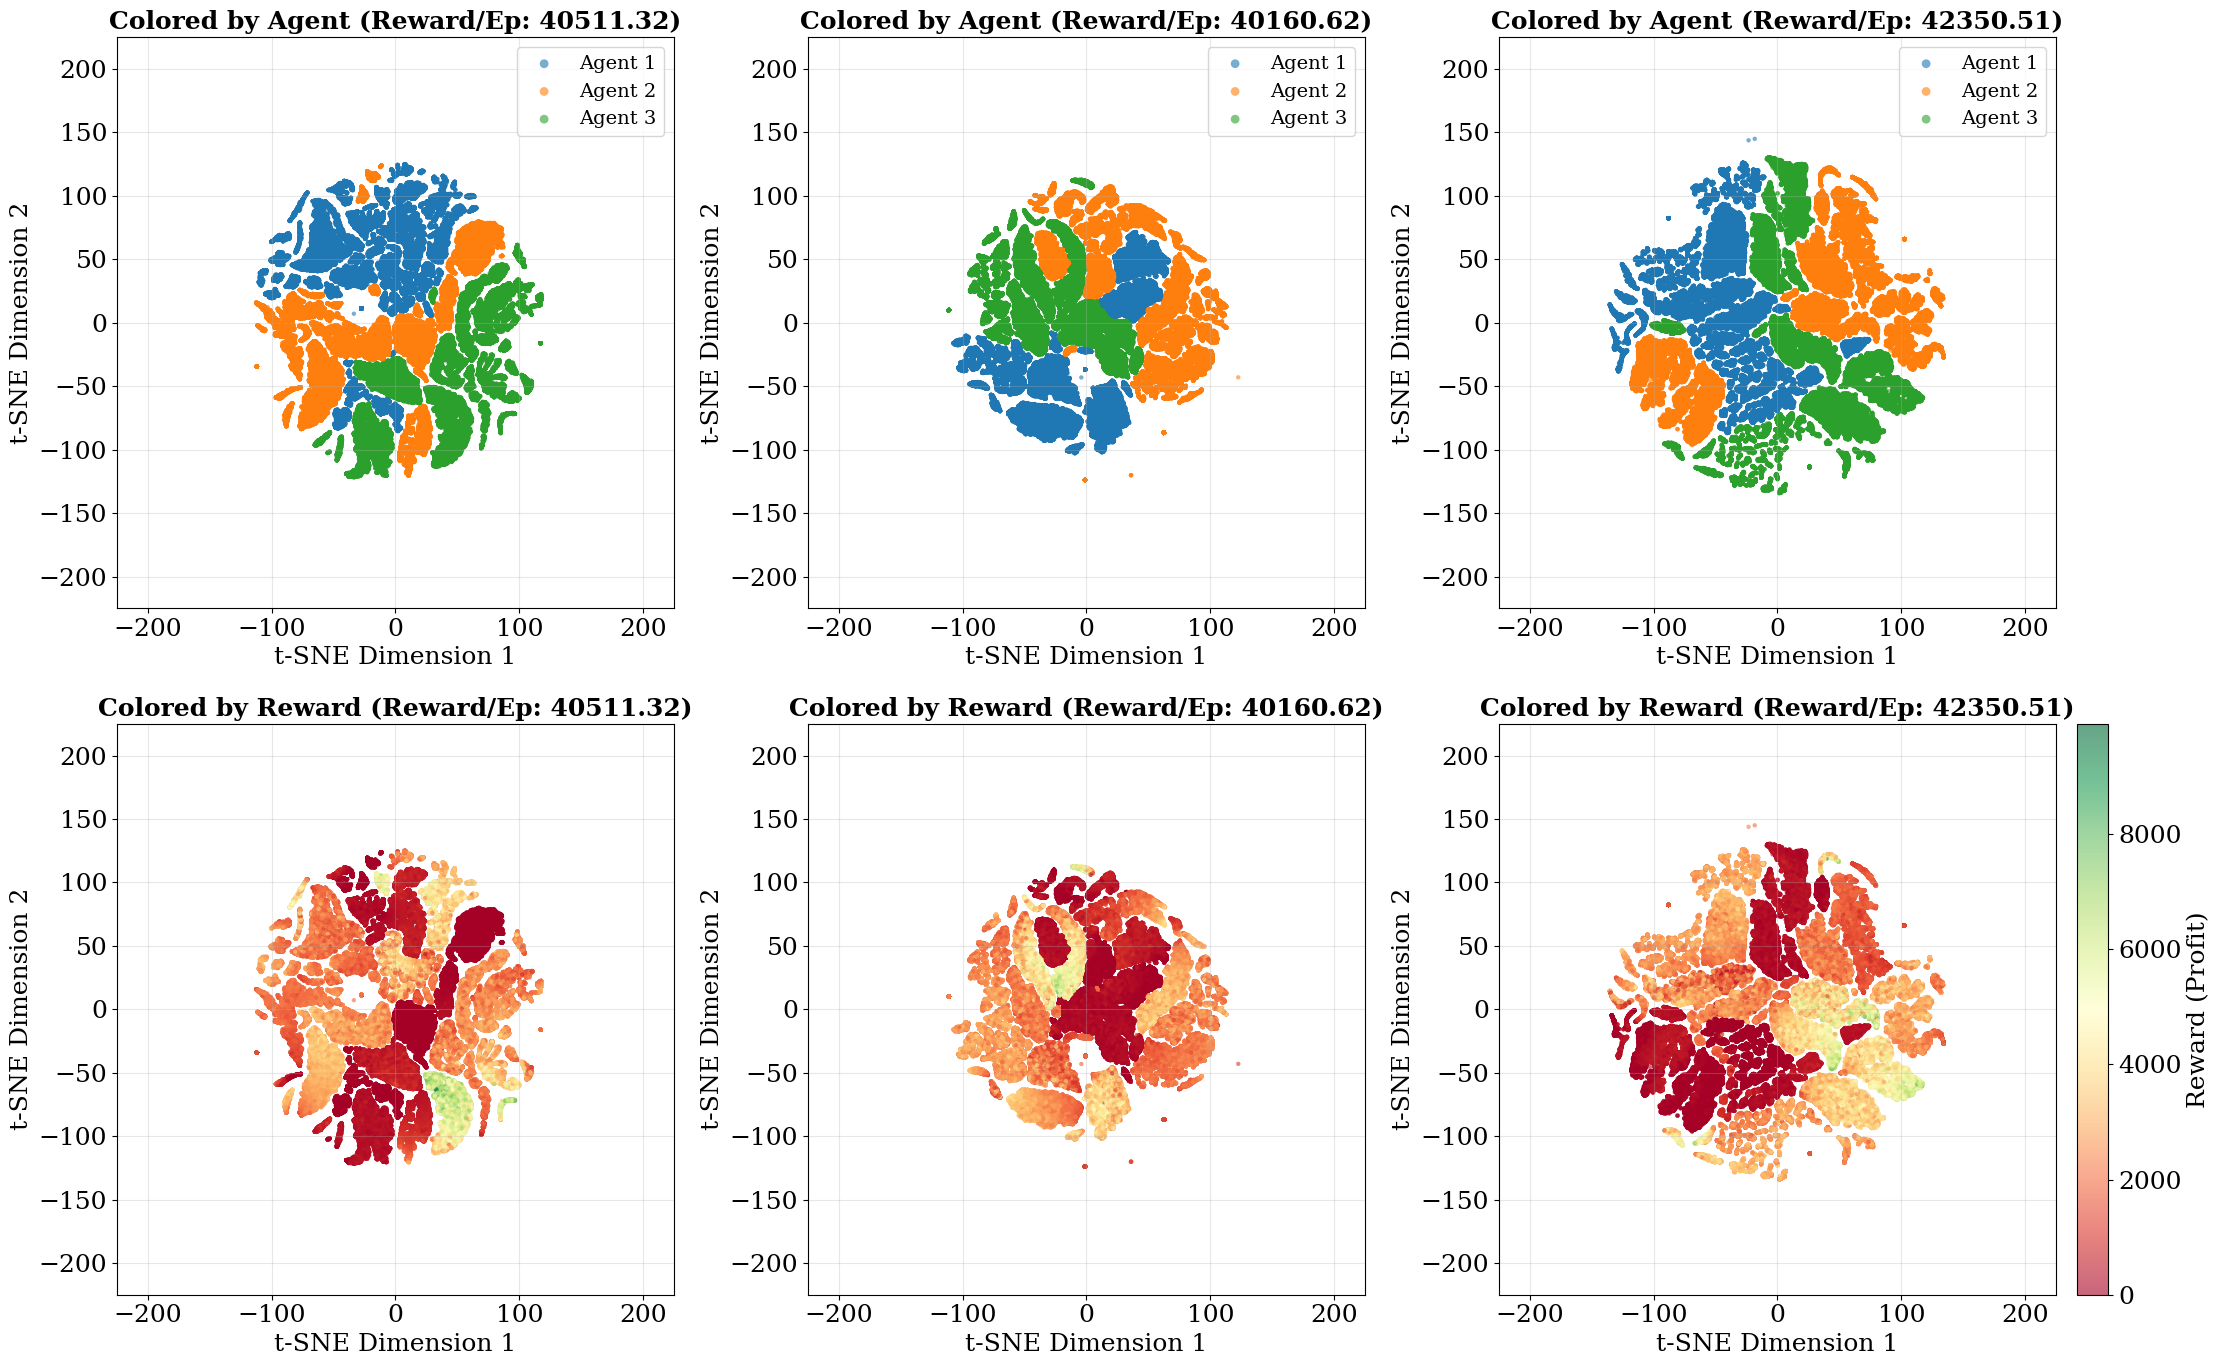

In [2]:
print("=== Creating Multi-Segment Figure (Column Layout) ===")
create_tsne_figure_columns(multi_segment_scenarios, 7, '', '/home/kinrre/Documentos/robin-rl/reports/tsne_base.pdf')

=== Creating Extended Figure (Column Layout) ===
Computing global reward scale...
  Global reward range: [0.00, 8865.38]
Processing scenario 1...
10000
  Running t-SNE on 400000 samples...


  Mean reward: 1406.58 (range: [0.00, 8865.38])
  Total reward per episode: 56263.26
Processing scenario 2...
10000
  Running t-SNE on 400000 samples...
  Mean reward: 1331.87 (range: [0.00, 7674.40])
  Total reward per episode: 53274.74
Processing scenario 3...
10000
  Running t-SNE on 400000 samples...
  Mean reward: 1302.50 (range: [0.00, 8741.15])
  Total reward per episode: 52100.12
Saved figure: /home/kinrre/Documentos/robin-rl/reports/tsne_large.pdf



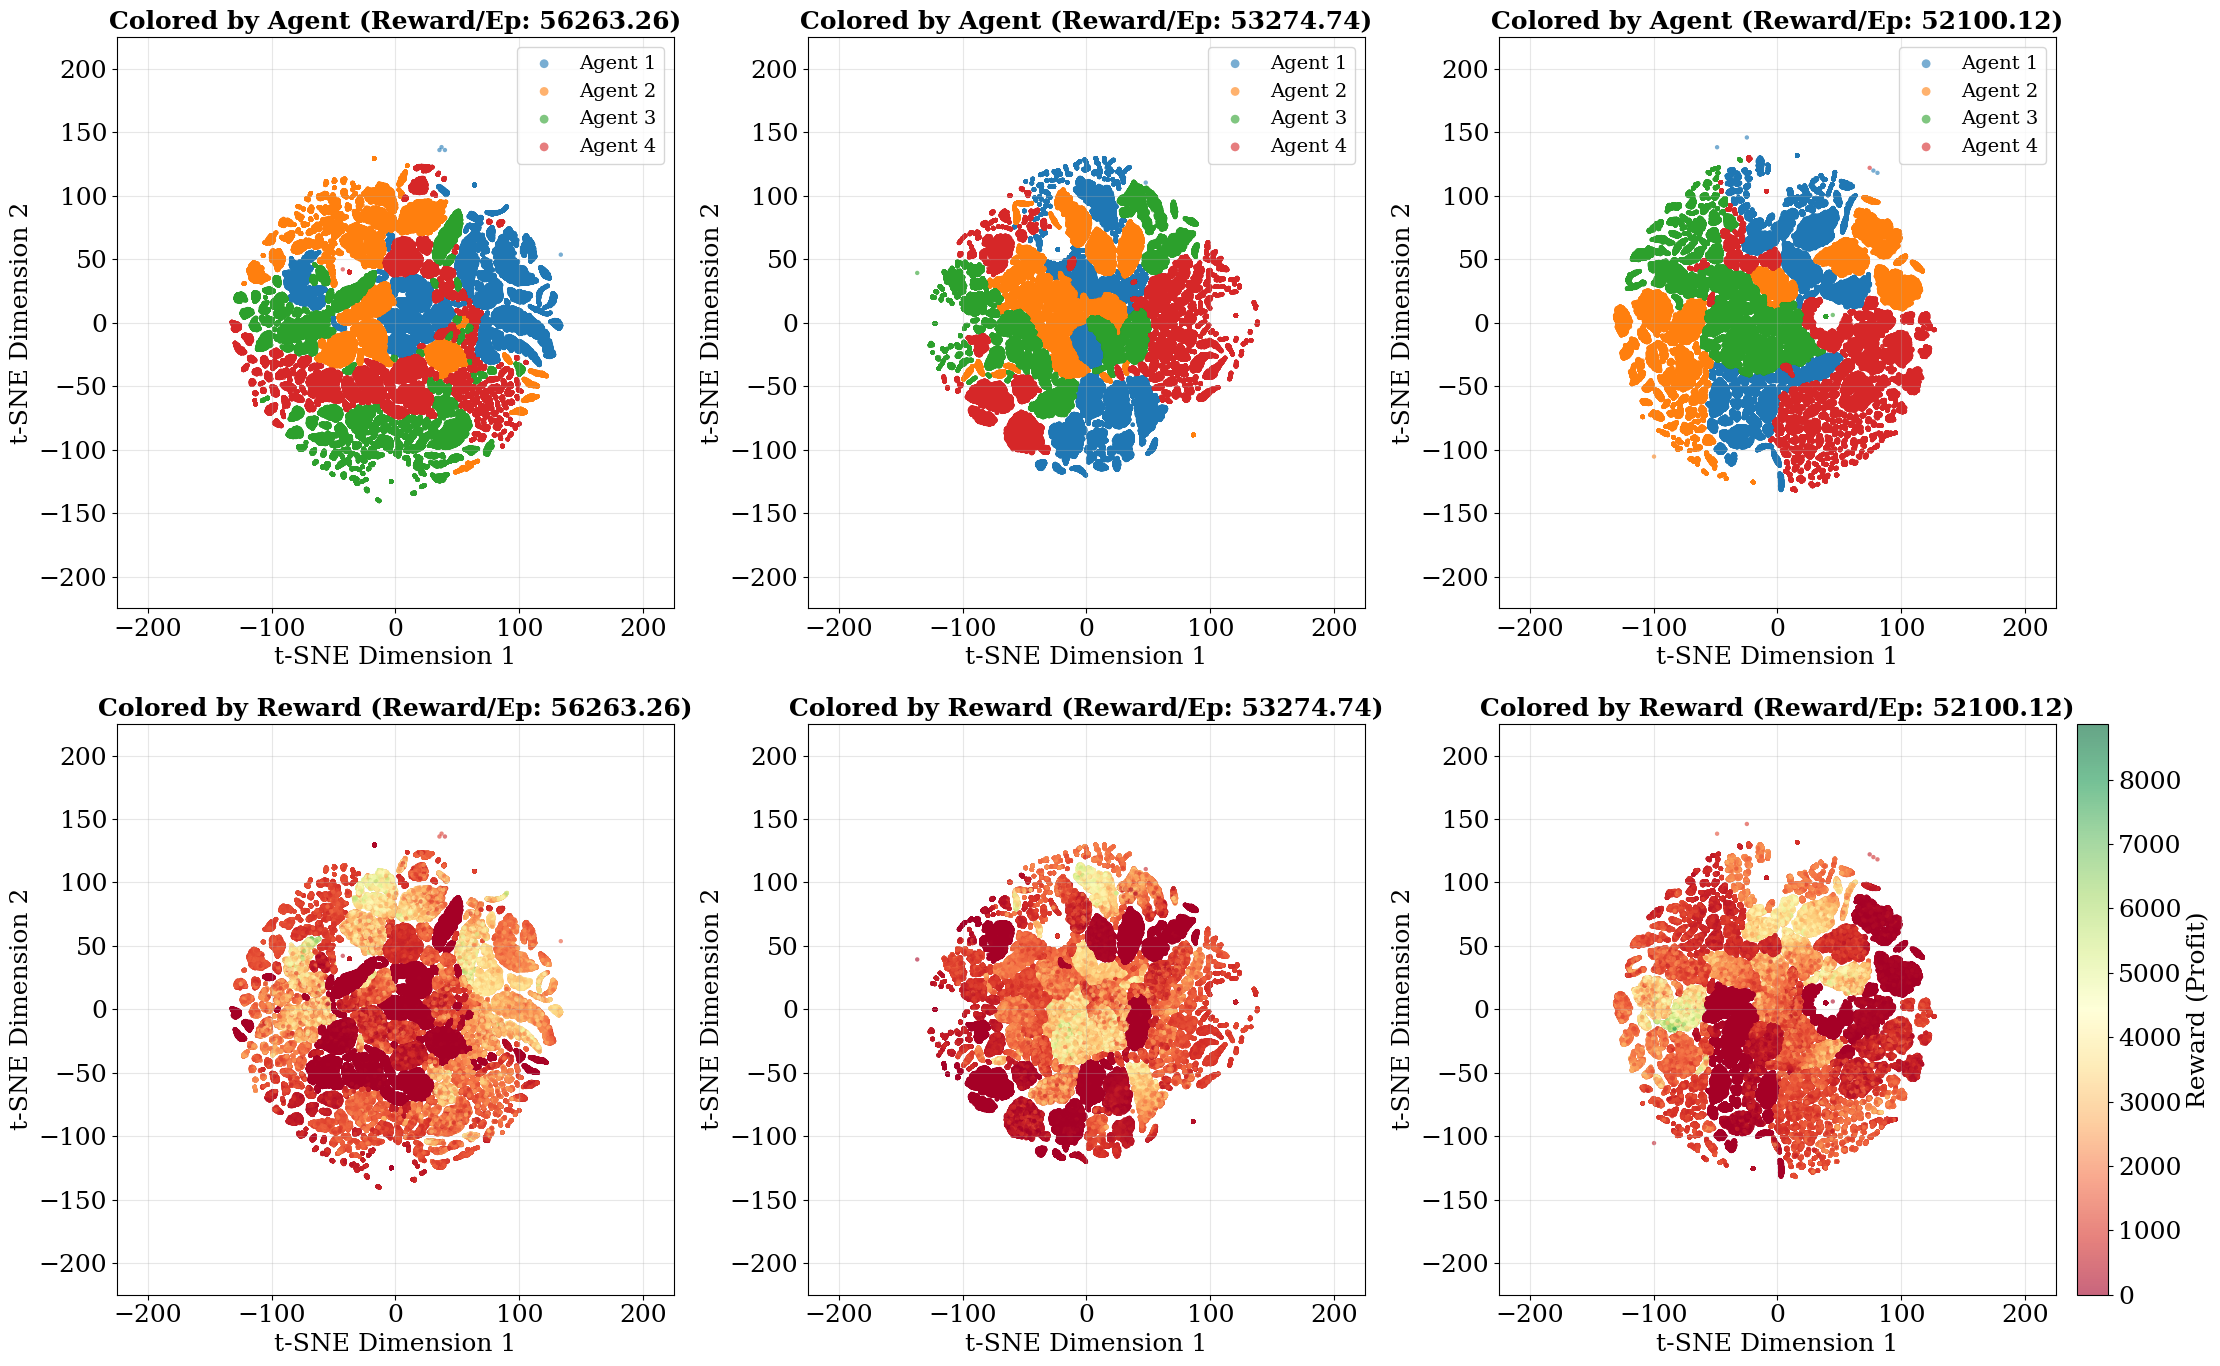

In [3]:
print("=== Creating Extended Figure (Column Layout) ===")
create_tsne_figure_columns(extended_scenarios, 10, '', '/home/kinrre/Documentos/robin-rl/reports/tsne_large.pdf')